# Predicting District-Level Literacy Rates in Pakistan

**A regression analysis using 2017 Pakistan Population Census data**


This notebook explores which district-level factors urbanization, employment, and housing quality are associated with literacy rate across Pakistan's 134 districts, and whether literacy rate differs significantly by province.


**Author:** Zohra | BS Statistics, University of the Punjab
**Data source:** 2017 Pakistan Population Census (via [colincookman/pakistan_census](https://github.com/colincookman/pakistan_census))


## 1. Setup

Import the libraries used throughout the analysis: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, `statsmodels` for regression and diagnostics, and `scikit-learn`/`scipy` for supporting utilities.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load the Data

Four census tables are used, each covering all of Pakistan's districts:

| Table | Contents |
|---|---|
| `table_13_literacy.csv` | Literacy ratio by district, gender, and area type (target variable) |
| `population.csv` | Population, urbanization %, household size, density |
| `imployment data..csv` | Population by employment/activity status |
| `housing data.csv` | Housing unit size and room counts |

In [7]:
import os
print(os.listdir(r"data"))

['housing data.csv', 'imployment data..csv', 'population.csv', 'table_13_literacy.csv']


In [8]:
literacy=pd.read_csv(r"data/table_13_literacy.csv")


In [9]:
population=pd.read_csv(r"data/population.csv")

In [10]:
housing=pd.read_csv(r"data/housing data.csv")

In [11]:
employment=pd.read_csv(r"data/imployment data..csv")
print(employment["work_activity"].unique())
print(employment["age_group"].unique())

['TOTAL POPULATION' 'WORKING' 'SEEKING WORK' 'STUDENT' 'HOUSEKEEPING'
 'OTHER']
['10 AND ABOVE' '10 - 14' '15 - 19' '20 - 24' '25 - 29' '30 - 34'
 '35 - 39' '40 - 44' '45 - 49' '50 - 54' '55 - 59' '60 - 64' '65 - 69'
 '70 - 74' '75 AND ABOVE']


In [12]:
housing.head(5)

,province_name,district_code,district_name,area_name,area_type,household_sizes,number_of_rooms,total_housing_units_by_hh_size,percent_of_total_units_by_hh_size,rooms_per_housing_unit,total_housing_units_by_room_size,percent_of_total_units_by_room_size,persons_per_housing_unit,count
0,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,1 PERSON,1,5112.0,2.39,1.94,35670.0,16.66,4.35,2491.0
1,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,2 PERSONS,1,14573.0,6.81,2.03,35670.0,16.66,4.35,5458.0
2,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,3 PERSONS,1,19924.0,9.30,2.22,35670.0,16.66,4.35,5685.0
3,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,4 PERSONS,1,28399.0,13.26,2.40,35670.0,16.66,4.35,6393.0
4,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,5 PERSONS,1,34964.0,16.33,2.58,35670.0,16.66,4.35,5906.0


In [13]:
employment.head(5)

,province_name,district_code,district_name,area_name,area_type,gender,work_activity,age_group,count
0,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,TOTAL POPULATION,10 AND ABOVE,1001575.0
1,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,TOTAL POPULATION,10 - 14,144607.0
2,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,TOTAL POPULATION,15 - 19,138183.0
3,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,TOTAL POPULATION,20 - 24,128627.0
4,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,TOTAL POPULATION,25 - 29,108763.0


In [14]:
population.head(5)

,province_name,district_code,district_name,area_name,area_type,area_sq_km,total_pop,total_male,total_female,total_trans,sex_ratio,pop_density,pct_urban,avg_hh_size,total_pop_98,avg_annual_growth
0,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,1967.0,1333089.0,677857.0,655196.0,36.0,103.46,677.73,22.05,6.08,880666.0,2.20
1,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,RURAL,NaN,1039104.0,522592.0,516494.0,18.0,101.18,NaN,NaN,6.05,722762.0,1.93
2,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,URBAN,NaN,293985.0,155265.0,138702.0,18.0,111.94,NaN,NaN,6.20,157904.0,3.32
3,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD TEHSIL,TOTAL,1438.0,982837.0,502980.0,479821.0,36.0,104.83,683.47,25.00,6.00,628766.0,2.37
4,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD TEHSIL,RURAL,NaN,737167.0,372331.0,364818.0,18.0,102.06,NaN,NaN,5.96,502487.0,2.03


In [16]:
literacy.head(5)

,province_name,district_code,district_name,area_name,area_type,gender,total_population,literacy_ratio,literacy_status,count
0,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,1001575,76.2,ILLITERATE,238360
1,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,1001575,76.2,TOTAL LITERATE,763215
2,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,1001575,76.2,FORMAL LITERATE,757652
3,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,ALL SEXES,1001575,76.2,INFORMAL LITERATE,5563
4,KHYBER PAKTUNKHWA,5,ABBOTTABAD DISTRICT,ABBOTTABAD DISTRICT,TOTAL,MALE,506703,86.4,ILLITERATE,68915


## 3. Data Cleaning

Each raw table mixes several things we don't want in one row per district:
- Multiple rows per district (by gender, area type, literacy/work status)
- Both district-level *and* tehsil-level rows under the same district

For each table, we filter down to **one row per district**: `area_type == "TOTAL"`, both sexes combined, and `area_name == district_name` (district-level row only, not a tehsil).

In [17]:
# --- Literacy: one row per district ---
literacy_clean = literacy[
    (literacy["area_type"] == "TOTAL") &
    (literacy["gender"] == "ALL SEXES") &
    (literacy["area_name"] == literacy["district_name"])
].drop_duplicates(subset="district_name")

literacy_clean = literacy_clean[["province_name", "district_name", "total_population", "literacy_ratio"]]

# --- Population: one row per district ---
population_clean = population[
    (population["area_type"] == "TOTAL") &
    (population["area_name"] == population["district_name"])
]
population_clean = population_clean[["district_name", "area_sq_km", "total_pop", "sex_ratio", "pop_density", "pct_urban", "avg_hh_size"]]

# --- Housing: one row per district ---
housing_clean = housing[
    (housing["area_type"] == "TOTAL") &
    (housing["area_name"] == housing["district_name"])
].drop_duplicates(subset="district_name")

housing_clean = housing_clean[["district_name", "rooms_per_housing_unit", "persons_per_housing_unit"]]

# --- Employment: one row per district, employment_rate = WORKING / TOTAL POPULATION ---
emp_filtered = employment[
    (employment["area_type"] == "TOTAL") &
    (employment["gender"] == "ALL SEXES") &
    (employment["age_group"] == "10 AND ABOVE") &
    (employment["area_name"] == employment["district_name"])
]

emp_pivot = emp_filtered.pivot_table(
    index="district_name",
    columns="work_activity",
    values="count"
).reset_index()

emp_pivot["employment_rate"] = (emp_pivot["WORKING"] / emp_pivot["TOTAL POPULATION"]) * 100
employment_clean = emp_pivot[["district_name", "employment_rate"]]

print("literacy_clean:", literacy_clean.shape)
print("population_clean:", population_clean.shape)
print("housing_clean:", housing_clean.shape)
print("employment_clean:", employment_clean.shape)

literacy_clean: (134, 4)
population_clean: (134, 7)
housing_clean: (135, 3)
employment_clean: (135, 2)


## 4. Merge Into One District-Level Dataset


Combine all four cleaned tables into a single table, joined on `district_name`.

In [19]:
df = literacy_clean.merge(population_clean, on="district_name", how="left")
df = df.merge(housing_clean, on="district_name", how="left")
df = df.merge(employment_clean, on="district_name", how="left")

print("Final merged dataset shape:", df.shape)
df.head(5)

Final merged dataset shape: (134, 13)


,province_name,district_name,total_population,literacy_ratio,area_sq_km,total_pop,sex_ratio,pop_density,pct_urban,avg_hh_size,rooms_per_housing_unit,persons_per_housing_unit,employment_rate
0,KHYBER PAKTUNKHWA,ABBOTTABAD DISTRICT,1001575,76.20,1967.0,1333089.0,103.46,677.73,22.05,6.08,1.94,4.35,29.255423
1,PUNJAB,ATTOCK DISTRICT,1446537,66.91,6857.0,1886378.0,99.06,275.10,26.02,6.09,2.24,4.42,27.093396
2,BALOCHISTAN,AWARAN DISTRICT,80350,25.47,29510.0,121821.0,107.34,4.13,28.10,6.61,1.68,4.55,19.286870
3,SINDH,BADIN DISTRICT,1211214,33.65,6858.0,1804958.0,106.59,263.19,21.63,5.00,1.17,4.75,27.339760
4,PUNJAB,BAHAWALNAGAR DISTRICT,2143179,53.08,8878.0,2975656.0,103.11,335.17,20.83,6.16,1.81,5.01,30.379030


## 5. Handle Missing Values

Check for missing data before analysis.

In [20]:
print(df.isnull().sum())

province_name                0
district_name                0
total_population             0
literacy_ratio               0
area_sq_km                   0
total_pop                    0
sex_ratio                    0
pop_density                  0
pct_urban                   15
avg_hh_size                  0
rooms_per_housing_unit       0
persons_per_housing_unit     0
employment_rate              0
dtype: int64


pct_urban` is missing for 15 districts. Checking which ones:

In [21]:
df[df["pct_urban"].isnull()][["district_name", "province_name"]]

,district_name,province_name
6,BAJAUR AGENCY,FATA
9,BATAGRAM DISTRICT,KHYBER PAKTUNKHWA
11,BUNER DISTRICT,KHYBER PAKTUNKHWA
22,FR BANNU,FATA
23,FR D.I.KHAN,FATA
24,FR KOHAT,FATA
25,FR LAKKI MARWAT,FATA
26,FR PESHAWAR,FATA
27,FR TANK,FATA
63,KOHISTAN DISTRICT,KHYBER PAKTUNKHWA


These are almost entirely remote, mountainous, or tribal districts (FATA agencies, Kohistan, Torghar, Sherani, Buner, Batagram) — places with no urban areas at all, which is why the urban % calculation came out blank rather than zero. We fill these with `0` (i.e., 0% urban / fully rural), since that's the correct interpretation rather than missing data.

In [22]:
df["pct_urban"] = df["pct_urban"].fillna(0)

# Confirm no more missing values
print(df.isnull().sum())

province_name               0
district_name               0
total_population            0
literacy_ratio              0
area_sq_km                  0
total_pop                   0
sex_ratio                   0
pop_density                 0
pct_urban                   0
avg_hh_size                 0
rooms_per_housing_unit      0
persons_per_housing_unit    0
employment_rate             0
dtype: int64


## 6. Exploratory Analysis

### 6.1 Distribution of literacy rate across districts

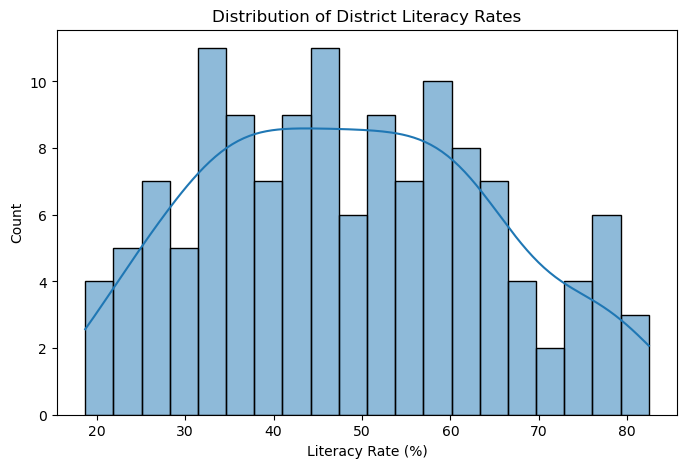

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["literacy_ratio"], bins=20, kde=True)
plt.title("Distribution of District Literacy Rates")
plt.xlabel("Literacy Rate (%)")
plt.show()

### 6.2 Literacy rate by province

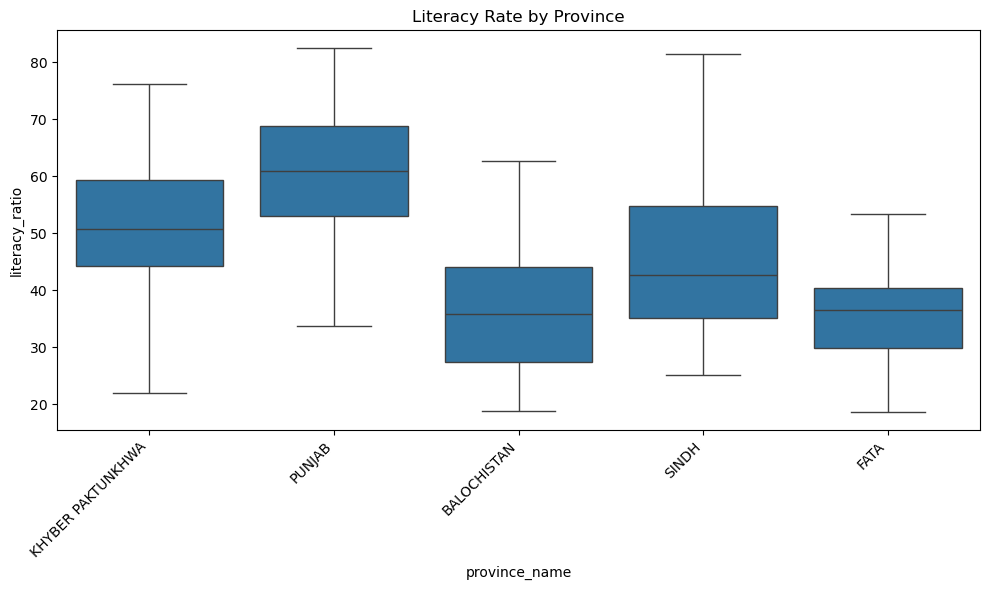

province_name
PUNJAB               61.674444
KHYBER PAKTUNKHWA    51.105600
SINDH                48.098966
BALOCHISTAN          37.406129
FATA                 34.936923
Name: literacy_ratio, dtype: float64


In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="province_name", y="literacy_ratio")
plt.xticks(rotation=45, ha="right")
plt.title("Literacy Rate by Province")
plt.tight_layout()
plt.show()

print(df.groupby("province_name")["literacy_ratio"].mean().sort_values(ascending=False))

### 6.3 Correlation with literacy rate


In [25]:
numeric_cols = ["literacy_ratio", "pct_urban", "avg_hh_size", "pop_density", "employment_rate", "rooms_per_housing_unit", "persons_per_housing_unit"]
print(df[numeric_cols].corr()["literacy_ratio"].sort_values(ascending=False))

literacy_ratio              1.000000
pct_urban                   0.553706
employment_rate             0.461878
pop_density                 0.375124
rooms_per_housing_unit      0.270997
avg_hh_size                -0.202531
persons_per_housing_unit   -0.230701
Name: literacy_ratio, dtype: float64


pct_urban` and `employment_rate` show the strongest relationships with literacy rate. Let's visualize both directly.

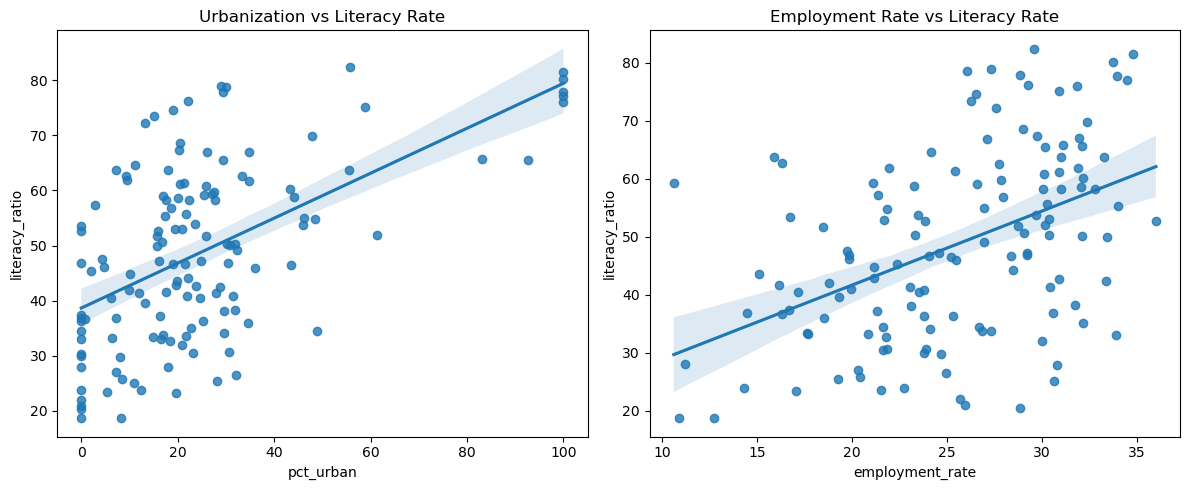

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.regplot(data=df, x="pct_urban", y="literacy_ratio", ax=axes[0])
axes[0].set_title("Urbanization vs Literacy Rate")

sns.regplot(data=df, x="employment_rate", y="literacy_ratio", ax=axes[1])
axes[1].set_title("Employment Rate vs Literacy Rate")

plt.tight_layout()
plt.show()

## 7. Regression Model

### 7.1 Full model (5 predictors)

Fit an OLS regression with all candidate predictors: urbanization, employment rate, population density, average household size, and rooms per housing unit.

In [27]:
X = df[["pct_urban", "employment_rate", "pop_density", "avg_hh_size", "rooms_per_housing_unit"]]
y = df["literacy_ratio"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         literacy_ratio   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.461
Method:                 Least Squares   F-statistic:                     23.74
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           7.83e-17
Time:                        22:58:50   Log-Likelihood:                -518.26
No. Observations:                 134   AIC:                             1049.
Df Residuals:                     128   BIC:                             1066.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

**Reading the output:** `pct_urban`, `employment_rate`, and `rooms_per_housing_unit` are statistically significant (p < 0.001). `pop_density` (p = 0.70) and `avg_hh_size` (p = 0.52) are not — so we simplify the model to just the significant predictors.

### 7.2 Check multicollinearity (VIF)

Before simplifying, check whether predictors overlap too much with each other (which would distort coefficients).

In [28]:
X_vif = df[["pct_urban", "employment_rate", "pop_density", "avg_hh_size", "rooms_per_housing_unit"]]
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                 variable         VIF
0                   const  113.018185
1               pct_urban    2.218716
2         employment_rate    1.528049
3             pop_density    1.735784
4             avg_hh_size    2.086676
5  rooms_per_housing_unit    1.464172


All predictor VIFs are between 1.4 and 2.2 — well under the common threshold of 5, so multicollinearity is not a concern. (The `const` row's VIF is always inflated and can be ignored.)

### 7.3 Simplified model (significant predictors only)

In [29]:
X_simple = df[["pct_urban", "employment_rate", "rooms_per_housing_unit"]]
X_simple = sm.add_constant(X_simple)

model_simple = sm.OLS(y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:         literacy_ratio   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     39.79
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           2.61e-18
Time:                        23:01:54   Log-Likelihood:                -518.58
No. Observations:                 134   AIC:                             1045.
Df Residuals:                     130   BIC:                             1057.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -4

Dropping the two non-significant predictors barely changed R-squared (0.481 -> 0.479), but **adjusted R-squared improved** (0.461 -> 0.467) and the condition number dropped sharply (5.19e+04 -> 274) — confirming the simpler model is the better one. This is our **final model**.

**In plain terms:** holding other factors constant,
- a 1-point increase in % urban population is associated with a ~0.32-point increase in literacy rate
- a 1-point increase in employment rate is associated with a ~0.87-point increase in literacy rate
- one additional room per housing unit (a wealth/living-space proxy) is associated with a ~12.5-point increase in literacy rate

Together, these three factors explain about **48%** of the variation in district literacy rates.

## 8. Model Diagnostics

### 8.1 Residual analysis

Check whether the regression assumptions hold: residuals should be randomly scattered around zero (no pattern) and roughly normally distributed.

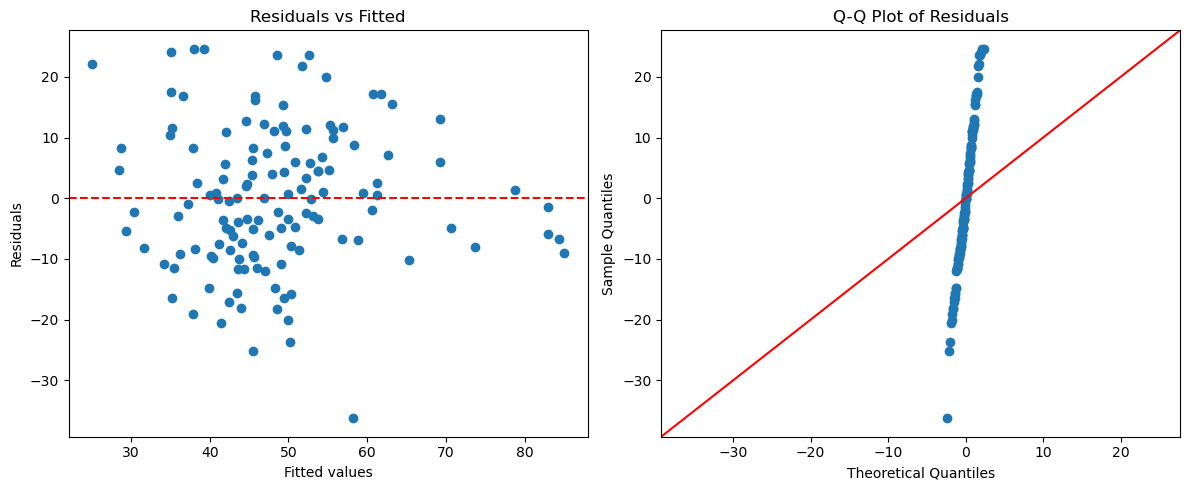

In [30]:
fitted = model_simple.fittedvalues
residuals = model_simple.resid

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(fitted, residuals)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

### 8.2 Influential points (Cook's Distance)

Check whether any single district is disproportionately driving the model's results.

        district_name  cooks_distance
63  KOHISTAN DISTRICT        0.257751
17      DADU DISTRICT        0.158527
98   PANJGUR DISTRICT        0.091003
53      KECH DISTRICT        0.061053
64     KOHLU DISTRICT        0.045811
25    FR LAKKI MARWAT        0.036578
50     KARAK DISTRICT        0.033871
6       BAJAUR AGENCY        0.033342
84     MOHMAND AGENCY        0.027498
22           FR BANNU        0.024505


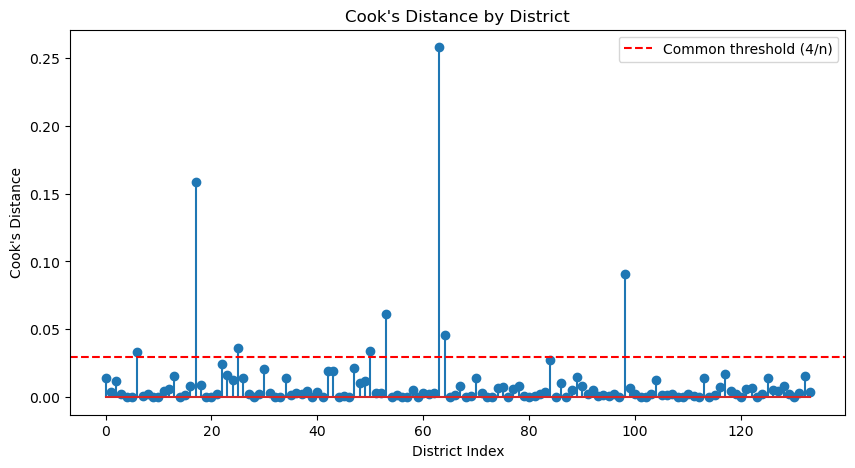

In [31]:
influence = model_simple.get_influence()
cooks_d = influence.cooks_distance[0]

df_influence = df[["district_name"]].copy()
df_influence["cooks_distance"] = cooks_d
df_influence = df_influence.sort_values("cooks_distance", ascending=False)

print(df_influence.head(10))

plt.figure(figsize=(10,5))
plt.stem(cooks_d)
plt.axhline(4/len(df), color='red', linestyle='--', label="Common threshold (4/n)")
plt.title("Cook's Distance by District")
plt.xlabel("District Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()

**Kohistan District** stands out clearly (Cook's distance = 0.26) — consistent with it being a remote, fully-rural mountain district (one of the districts where `pct_urban` was filled with 0). Let's check whether removing it changes the model's conclusions.

### 8.3 Sensitivity check — model without Kohistan

In [32]:
df_no_outlier = df[df["district_name"] != "KOHISTAN DISTRICT"]

X_check = df_no_outlier[["pct_urban", "employment_rate", "rooms_per_housing_unit"]]
X_check = sm.add_constant(X_check)
y_check = df_no_outlier["literacy_ratio"]

model_check = sm.OLS(y_check, X_check).fit()
print(model_check.summary())

                            OLS Regression Results                            
Dep. Variable:         literacy_ratio   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     44.82
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           6.50e-20
Time:                        23:05:42   Log-Likelihood:                -509.66
No. Observations:                 133   AIC:                             1027.
Df Residuals:                     129   BIC:                             1039.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -8

Removing Kohistan slightly **improves** R-squared (0.479 -> 0.510) and all three predictors remain significant with similar coefficients. **The model is robust** — Kohistan is influential but does not distort the overall conclusions.

## 9. Province Comparison

The regression above controls for urbanization, employment, and housing — but does province itself still matter? A one-way ANOVA tests whether mean literacy rate differs significantly across provinces.

In [33]:
province_groups = [group["literacy_ratio"].values for name, group in df.groupby("province_name")]

f_stat, p_value = stats.f_oneway(*province_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 18.543336690102553
P-value: 4.630580252670079e-12


The p-value is essentially zero — provinces differ significantly in literacy rate, not due to chance. To see **which** provinces differ from which, run a Tukey HSD post-hoc test.

In [34]:
tukey = pairwise_tukeyhsd(endog=df["literacy_ratio"], groups=df["province_name"], alpha=0.05)
print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------
      BALOCHISTAN              FATA  -2.4692 0.9788 -14.3982  9.4598  False
      BALOCHISTAN KHYBER PAKTUNKHWA  13.6995 0.0014    3.995  23.404   True
      BALOCHISTAN            PUNJAB  24.2683    0.0  15.4225 33.1141   True
      BALOCHISTAN             SINDH  10.6928  0.016   1.3662 20.0195   True
             FATA KHYBER PAKTUNKHWA  16.1687 0.0038    3.824 28.5134   True
             FATA            PUNJAB  26.7375    0.0  15.0558 38.4192   True
             FATA             SINDH   13.162 0.0248   1.1121  25.212   True
KHYBER PAKTUNKHWA            PUNJAB  10.5688 0.0191     1.17 19.9677   True
KHYBER PAKTUNKHWA             SINDH  -3.0066 0.9162 -12.8594  6.8461  False
           PUNJAB             SINDH -13.5755 0.0005 -22.5837 -4.5673   True
------------

**Summary of province differences:**
- **Punjab** has significantly higher literacy than every other province
- **Balochistan and FATA** form a lower tier, not significantly different from each other
- **Khyber Pakhtunkhwa and Sindh** sit in between, not significantly different from each other

## 10. Conclusion

**Key findings:**
1. Urbanization, employment rate, and housing quality (rooms per housing unit) are all significant, positive predictors of district literacy rate, together explaining ~48% of the variation.
2. The model shows no multicollinearity issues and passes residual diagnostic checks; its conclusions are robust to the most influential outlier (Kohistan District).
3. Provinces differ significantly in literacy rate even beyond what these factors explain — Punjab leads, Balochistan and FATA lag, and KP/Sindh sit in between.

**Limitations:**
- Cross-sectional data (2017 only) — no time trend
- ~52% of the variation in literacy rate is unexplained by this model; results describe association, not causation
- District-level aggregation masks within-district variation

**Next step:** build an interactive dashboard (Streamlit/Plotly Dash) to explore literacy rate by district and province.
